In [13]:
##### SI Figure 6: actual vs predicted intensities plot

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent.parent

# import reference data 
ref_data = pd.read_csv(f"{cd}/Data/Clean/Intensities/intensities_for_eval.csv")

# import model predictions
capital_rf = pd.read_parquet(f'{cd}/Results/RF_models_final/capital_rf_spatial_CV/predictions.parquet')
labor_rf = pd.read_parquet(f'{cd}/Results/RF_models_final/labor_rf_spatial_CV/predictions.parquet')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/FINAL_FIGURES"

In [15]:
##### PREP DATA

# Add original intensity data (sub-national and country) for evaluation
capital_rf = capital_rf.merge(ref_data, on=['PROJ_ID', 'country_ID'], how='left')
labor_rf = labor_rf.merge(ref_data, on=['PROJ_ID', 'country_ID'], how='left')

# Calculate absolute predicted intensity (not relative)
capital_rf['predicted_log_capital_intensity_USD_per_million_tonne'] = capital_rf['prediction'] + capital_rf['log_country_capital_intensity_USD_per_million_tonne']
labor_rf['predicted_log_labor_intensity_jobs_per_million_tonne'] = labor_rf['prediction'] + labor_rf['log_country_labor_intensity_jobs_per_million_tonne']

# Calculate actual relative intensity 
capital_rf['actual_capital_rtv'] = capital_rf['log_region_capital_intensity_USD_per_million_tonne'] - capital_rf['log_country_capital_intensity_USD_per_million_tonne']
labor_rf['actual_labor_rtv'] = labor_rf['log_region_labor_intensity_jobs_per_million_tonne'] - labor_rf['log_country_labor_intensity_jobs_per_million_tonne']

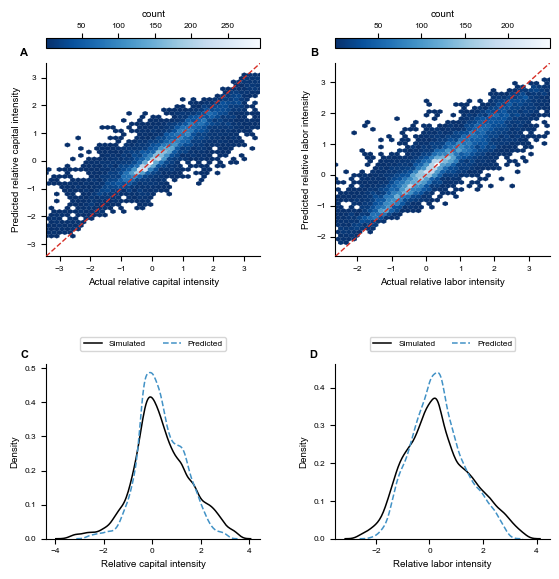

In [20]:
##### Combined figure: actual vs predicted (hexbin) + density comparison

# set fonts
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]

# Hexplot of actual vs predicted
def hexbin_panel(ax, cax, x, y, xlabel, ylabel, panel_label, gridsize=40):
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]

    cmap = plt.cm.Blues_r  
    hb = ax.hexbin(x, y, gridsize=gridsize, cmap=cmap, mincnt=1, linewidths=0.1)

    # colorbar above panel
    cbar = fig.colorbar(hb, cax=cax, orientation="horizontal")
    cbar.ax.xaxis.set_ticks_position("top")
    cbar.ax.xaxis.set_label_position("top")
    cbar.set_label("count", fontsize=7)
    cbar.ax.tick_params(labelsize=6)

    # 1:1 reference line 
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, color="#d73027", linestyle="--", linewidth=1, zorder=3)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel(ylabel, fontsize=7)
    ax.tick_params(axis="both", labelsize=6)
    ax.text(-0.12, 1.08, panel_label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", ha="left")
    ax.spines[["top", "right"]].set_visible(False)

# KDE of actual vs predicted
def density_panel(ax, actual, predicted, xlabel, panel_label):
    mask = actual.notna() & predicted.notna()
    actual, predicted = actual[mask], predicted[mask]

    sns.kdeplot(actual, ax=ax, color="black", linestyle="-",
                linewidth=1.1, label="Simulated")
    sns.kdeplot(predicted, ax=ax, color="#4292c6", linestyle="--",
                linewidth=1.1, label="Predicted")

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2,
              frameon=True, fontsize=6, handlelength=2.2)
    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel("Density", fontsize=7)
    ax.tick_params(axis="both", labelsize=6)
    ax.text(-0.12, 1.08, panel_label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", ha="left")
    ax.spines[["top", "right"]].set_visible(False)


# ---- build the 2x2 figure ----
fig = plt.figure(figsize=(6.5, 6.5))
gs = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[1, 0.8], hspace=0.55, wspace=0.35)

# reserve slim axes above each hexbin panel for its colorbar
gs_top = gs[0, 0].subgridspec(2, 1, height_ratios=[0.05, 1], hspace=0.15)
ax_a = fig.add_subplot(gs_top[1])
cax_a = fig.add_subplot(gs_top[0])

gs_top_b = gs[0, 1].subgridspec(2, 1, height_ratios=[0.05, 1], hspace=0.15)
ax_b = fig.add_subplot(gs_top_b[1])
cax_b = fig.add_subplot(gs_top_b[0])

ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# panel A: capital hexbin
hexbin_panel(
    ax_a, cax_a,
    capital_rf['actual_capital_rtv'],
    capital_rf['prediction'],
    "Actual relative capital intensity", "Predicted relative capital intensity", "A"
)

# panel B: labor hexbin
hexbin_panel(
    ax_b, cax_b,
    labor_rf['actual_labor_rtv'],
    labor_rf['prediction'],
    "Actual relative labor intensity", "Predicted relative labor intensity", "B"
)

# panel C: capital density
density_panel(
    ax_c,
    capital_rf['actual_capital_rtv'],
    capital_rf['prediction'],
    "Relative capital intensity", "C"
)

# panel D: labor density
density_panel(
    ax_d,
    labor_rf['actual_labor_rtv'],
    labor_rf['prediction'],
    "Relative labor intensity", "D"
)

# facecolor="white" avoids a transparent/alpha background; matplotlib's raster
# TIFF export is already flattened to a single layer and in RGB mode.
fig.savefig(f"{fd}/SI_fig_6_actual_predicted.tiff", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()